## Utils

In [1]:
import pandas as pd
import duckdb
import numpy as np
import seaborn as sns 
from scipy import stats
import matplotlib.pyplot as plt

import sys
import os
sys.path.append(os.path.abspath(os.path.join('..'))) 

from src.charts import compute_conversion_table 
from src.statistical_tests import *

def perform_data_checks(df):
    
    null_counts = df.isnull().sum()
    if null_counts.sum() == 0:
        print("""
        No missing values found. """)
    else:
        print("""
        Missing values found:""")
        print(null_counts[null_counts > 0])

    
    if df.duplicated().sum() == 0:
        print("""
        No duplicate rows found. """)
    else:
        print("""
        Duplicate rows found. """)

    
    numeric_cols = df.select_dtypes(include=['number'])
    for col in numeric_cols:
        
        threshold = 2
        z_scores = (df[col] - df[col].mean()) / df[col].std()
        outliers = df[abs(z_scores) > threshold]
        if outliers.empty:
            print(f"""
            No outliers found in column '{col}'. """)
        else:
            print(f"""
            Outliers found in column '{col}': """)

def add_date_columns(df, date_col='date'):
    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col], errors='coerce')
    out['year'] = out[date_col].dt.year 
    out["week_year"] = out[date_col].dt.to_period("W")
    out['month_year'] = out[date_col].dt.to_period('M').astype(str)
    out['quarter_year'] = out[date_col].dt.to_period('Q').astype(str)
    return out

def fix_date_column(df, date_col='date', drop_invalid=True, verbose=True):
    out = df.copy()
    raw = out[date_col].astype(str).str.strip()

    # format='mixed' infers per-element, covering both M/D/YY and ISO YYYY-M-D.
    # errors='coerce' -> NaT for anything impossible/unparseable.
    parsed = pd.to_datetime(raw, format='mixed', dayfirst=False, errors='coerce')

    bad_mask = parsed.isna()
    n_bad = int(bad_mask.sum())

    if verbose and n_bad:
        print(f"[fix_date_column] {n_bad} unparseable/impossible date(s) found:")
        print(raw[bad_mask].value_counts().to_string())

    out[date_col] = parsed

    if drop_invalid:
        out = out[~bad_mask].copy()
        if verbose:
            print(f"[fix_date_column] dropped {n_bad} row(s); "
                  f"{len(out)} of {len(df)} rows remain.")

    return out

def clean_data(): 
    
    df_dedups = duckdb.query(f"""
    select 
        date
        , country
        , marketing_channel
        , signups
        , kyc_init	
        , kyc_complete
        , card_activation	
        , first_transaction
    from (
        select *
            , ROW_NUMBER() over(PARTITION by date, country, marketing_channel) as rn 
        from n26_funnel 
    )
    where rn = 1       
""").to_df()
    
    df = fix_date_column(df_dedups, date_col='date', drop_invalid=True, verbose=True)
    return df

def zscore_outlier_scan(df, value_cols, volume_col='signups', sigma=3): 
    flags = pd.DataFrame(index=df.index)
    summary = []

    for c in value_cols:
        z = np.abs(stats.zscore(df[c]))
        is_out = z > sigma
        flags[c] = is_out
        summary.append({
            'column': c,
            'skewness': round(stats.skew(df[c]), 3),   
            'n_outliers': int(is_out.sum()),
            'pct_outliers': round(is_out.mean(), 3),
        })

    out = df.copy()
    out['n_outlier_cols'] = flags.sum(axis=1)

    has_out = out['n_outlier_cols'] > 0
    print(f"Rows flagged in >=1 column (|z|>{sigma}): {has_out.sum()} / {len(out)} = % {round(has_out.sum() / len(out) * 100, 1)} ")
    print(f"  Flagged rows - median {volume_col}: {out.loc[has_out, volume_col].median():.0f}")
    print(f"  Clean rows   - median {volume_col}: {out.loc[~has_out, volume_col].median():.0f}")

    return pd.DataFrame(summary), out

def conversion_table(df, group_by):  
    if group_by: 
        g = df.groupby(group_by)[['signups', 'kyc_init', 'kyc_complete', 'card_activation', 'first_transaction']].sum()
    else:
        g = df[['signups', 'kyc_init', 'kyc_complete', 'card_activation', 'first_transaction']].sum().to_frame().T

    out = pd.DataFrame(index=g.index)
    out['su_kyci_cr']   = g.kyc_init          / g.signups           
    out['kyci_kycc_cr'] = g.kyc_complete      / g.kyc_init         
    out['kycc_card_cr'] = g.card_activation   / g.kyc_complete      
    out['card_ft_cr']   = g.first_transaction / g.card_activation  
    out['su_ft_cr']     = g.first_transaction / g.signups           

    out['su_kyci_dr'] = 1 - out['su_kyci_cr']
    out['kyci_kycc_dr'] = 1 - out['kyci_kycc_cr']
    out['kycc_card_dr'] = 1 - out['kycc_card_cr']
    out['card_ft_dr'] = 1 - out['card_ft_cr']
    out['su_ft_dr'] = 1 - out['su_ft_cr']

    out = out.join(g)  
 
    return out.reset_index()

def plot_kde(df, aggregation_level="month_year", rate_type = "conversion"):
    unique_aggregates = df[aggregation_level].unique()
    if aggregation_level == "month_year":
        rows, cols = 9, 4
    elif aggregation_level == "quarter_year":
        rows, cols = 4, 3
    elif aggregation_level == "year":
        rows, cols = 1, 3 
    else:
        raise ValueError("Invalid aggregation level. Choose from 'month_year', 'quarter_year', or 'year'.")

    fig, axes = plt.subplots(rows, cols, figsize=(15, 8), constrained_layout=True)
    axes = axes.flatten()
    
    for i, aggregate in enumerate(unique_aggregates):
        subset = df[df[aggregation_level] == aggregate]
        ax = axes[i]
        if rate_type == "conversion":
            sns.kdeplot(data=subset, x="su_kyci_cr", label="su_kyci_cr", fill=True, ax=ax)
            sns.kdeplot(data=subset, x="kyci_kycc_cr", label="kyci_kycc_cr", fill=True, ax=ax)
            sns.kdeplot(data=subset, x="kycc_card_cr", label="kycc_card_cr", fill=True, ax=ax)
            sns.kdeplot(data=subset, x="card_ft_cr", label="card_ft_cr", fill=True, ax=ax)
        else:
            sns.kdeplot(data=subset, x="su_kyci_dr", label="su_kyci_dr", fill=True, ax=ax)
            sns.kdeplot(data=subset, x="kyci_kycc_dr", label="kyci_kycc_dr", fill=True, ax=ax)
            sns.kdeplot(data=subset, x="kycc_card_dr", label="kycc_card_dr", fill=True, ax=ax)
            sns.kdeplot(data=subset, x="card_ft_dr", label="card_ft_dr", fill=True, ax=ax)
        ax.set_title(f"{aggregate}")
        ax.set_xlabel("")
        ax.legend()

    for j in range(len(unique_aggregates), len(axes)):
        axes[j].axis("off")

    plt.show()

## Task 1: Funnel Performance & Channel Effectiveness
 
### Read on the data first
 
Before any channel comparison, I want to be upfront about what this dataset is, because it changes how the rest of the questions should be answered.
 
The funnel is engineered to be flat. Conversion is near-identical across every channel, every country, and every month in the three-year window. That is not a real-world acquisition pattern, so the honest job here is not to crown a "best" channel out of noise. It is to prove the flatness convincingly, then answer the underlying questions the way I would on real data and name exactly what is missing.
 
One test does most of the work. I pooled signups and first transactions to channel level and ran a chi-square of channel against first-transaction conversion. With 1.22M signups the test is massively overpowered: at that sample size even a tenth-of-a-point real gap would light up as significant. It does not. The result is χ² = 9.8, dof = 10, p = 0.46, Cohen's w = 0.003. A w of 0.003 sits two orders of magnitude below the 0.1 "small effect" line. So the channels are not just close. They are statistically indistinguishable end to end, and that is hard to produce by accident.
 
So the real task here is not picking a winner. It is proving the flatness, then answering each question the way I would on real data and naming what the dataset cannot tell me.

### Q1: Consolidated funnel, and what "channel effectiveness" should actually measure
 
**Plan** 

First I build the funnel from raw counts at the correct grain, then I decide which metrics belong to the question. 

The granularity of the data should be on date-country-channel. and for deduplication, I chose to keep the first occurance instead of summing or dropping them. 

Then I separate the two kinds of "effectiveness" metric, the ones that diagnose the funnel and the ones that justify spend, because the case treats them as one and they are not.

In [2]:
n26_funnel = pd.read_csv("../data/part_a_dataset.csv")

df = clean_data()
df = add_date_columns(df, date_col='date')

perform_data_checks(df)

[fix_date_column] 70 unparseable/impossible date(s) found:
date
2019-2-29    14
2018-2-29    13
2017-2-29    13
2019-2-30    11
2017-2-30    10
2018-2-30     9
[fix_date_column] dropped 70 row(s); 12094 of 12164 rows remain.

        No missing values found. 

        No duplicate rows found. 

            No outliers found in column 'signups'. 

            No outliers found in column 'kyc_init'. 

            No outliers found in column 'kyc_complete'. 

            No outliers found in column 'card_activation'. 

            No outliers found in column 'first_transaction'. 

            No outliers found in column 'year'. 


In [3]:
df[["signups","kyc_init","kyc_complete","card_activation","first_transaction"]].describe()

,signups,kyc_init,kyc_complete,card_activation,first_transaction
count,12094.000000,12094.000000,12094.000000,12094.000000,12094.000000
mean,95.020506,75.009426,54.950141,45.055234,34.960972
std,3.173853,3.179398,3.169969,3.173673,3.160232
min,90.000000,70.000000,50.000000,40.000000,30.000000
25%,92.000000,72.000000,52.000000,42.000000,32.000000
50%,95.000000,75.000000,55.000000,45.000000,35.000000
75%,98.000000,78.000000,58.000000,48.000000,38.000000
max,100.000000,80.000000,60.000000,50.000000,40.000000


In [4]:
compute_conversion_table(df)

,Stage,Volume,% of Signup,% of Previous,Drop-off,Drop-off % of Previous,Drop-off % of Signup
0,Signup,1149178,1.000000,100.000000,NaN,NaN,NaN
1,KYC Initiated,907164,0.789403,0.789403,242014.0,0.210597,0.210597
2,KYC Completed,664567,0.578298,0.732576,242597.0,0.267424,0.421702
3,Card Activated,544898,0.474163,0.819929,119669.0,0.180071,0.525837
4,First Transaction,422818,0.367931,0.775958,122080.0,0.224042,0.632069


**Answer** 

Aggregated across the full dataset, the funnel reads:
 
| Step | Conversion | Drop |
|---|---|---|
| Signup to KYC init | 78.9% | 21.1% |
| KYC init to KYC complete | **73.3%** | **26.7%** |
| KYC complete to Card activation | 82.0% | 18.0% |
| Card activation to First transaction | 77.6% | 22.4% |
| **Signup to First transaction** | **36.8%** | **63.2%** |
 
End to end, 36.8% of signups reach a first transaction. The interactive version is the Streamlit app(**https://n26case-korcankomili.streamlit.app/**), with sidebar filters, a breakdown toggle, and an expandable step table. 

The consolidated view and any channel or country cut come from the same `conversion_table()` function, so the numbers reconcile across views.
 
On metrics: step conversion and step drop-off are the right __diagnostic__ measures. They tell me where the funnel leaks. They are the wrong measure for an investment decision, because they say nothing about what a channel costs or what it returns. For "where do we put the next euro," the metric I would use LTV/CAC, with CAC built from spend and LTV from downstream revenue or retention. Neither input exists in this dataset. There is no spend column, so no CAC. There is no revenue or LTV, so no ROI(ROAS). Without those I cannot rank channels on efficiency, and I cannot build an MMM to find where the marginal euro pays off.
 
The funnel tells me how users move. It does not tell me which users are worth acquiring or what they cost, and that gap drives every channel answer below.

### Q2: Step-level and channel comparison: where the gaps are, and the anomalies
 
**Plan** 

I compare each step and the full funnel across all 11 channels, then I test whether the differences I see are real or sampling noise. 

A raw spread is not enough on its own, so I check three things: the effect size behind the spread, the stability of conversion over time, and whether the row-level "outliers" carry any signal. If all three point the same way, the read is solid.

In [5]:
mc_cr = conversion_table(df, group_by="marketing_channel")
mc_cr[["marketing_channel", 'su_kyci_cr', 'kyci_kycc_cr', 'kycc_card_cr', 'card_ft_cr','su_ft_cr']]

,marketing_channel,su_kyci_cr,kyci_kycc_cr,kycc_card_cr,card_ft_cr,su_ft_cr
0,affiliate,0.788893,0.733642,0.819864,0.776557,0.368483
1,app store,0.787312,0.733419,0.820180,0.778148,0.368528
2,brand influencer,0.788822,0.736505,0.812455,0.770590,0.363728
3,direct,0.790224,0.732304,0.817703,0.778428,0.368345
4,display,0.789215,0.732252,0.819521,0.773876,0.366511
5,friend referral,0.790195,0.730556,0.824720,0.771135,0.367134
6,organic search,0.790732,0.730653,0.822859,0.777625,0.369688
7,other organic,0.789659,0.733426,0.815918,0.775873,0.366634
8,paid search,0.788504,0.732809,0.819404,0.779282,0.368967
9,paid social,0.789184,0.733575,0.820057,0.771199,0.366128


In [6]:
c_cr = conversion_table(df, group_by="country")
c_cr[["country", 'su_kyci_cr', 'kyci_kycc_cr', 'kycc_card_cr', 'card_ft_cr','su_ft_cr']]

,country,su_kyci_cr,kyci_kycc_cr,kycc_card_cr,card_ft_cr,su_ft_cr
0,BEL,0.788515,0.733517,0.818890,0.775440,0.367277
1,DEU,0.791450,0.730672,0.819819,0.775358,0.367592
2,ESP,0.788198,0.732291,0.822098,0.772415,0.366516
3,EST,0.790519,0.730799,0.824663,0.771799,0.367698
4,FRA,0.787715,0.735511,0.820032,0.775002,0.368207
5,GRC,0.788660,0.733286,0.819100,0.782673,0.370750
6,IRL,0.789126,0.733351,0.816830,0.779204,0.368334
7,ITA,0.789306,0.733800,0.817337,0.780142,0.369316
8,NOR,0.793404,0.728436,0.819094,0.771259,0.365107
9,POL,0.792443,0.732016,0.819011,0.776832,0.369067


In [7]:
_COUNTS = ["signups", "kyc_init", "kyc_complete", "card_activation", "first_transaction"]

_FUNNEL_STEPS = [
    ("su_kyci",   "signups",          "kyc_init"),
    ("kyci_kycc", "kyc_init",         "kyc_complete"),
    ("kycc_card", "kyc_complete",     "card_activation"),
    ("card_ft",   "card_activation",  "first_transaction"),
    ("su_ft",     "signups",          "first_transaction"),
]

chi2_by_step(df = df, group_col = "marketing_channel", counts = _COUNTS, steps = _FUNNEL_STEPS)

,step,n,chi2,dof,p,cohens_w,band
0,su_kyci,1149178,7.14,10,0.712,0.0025,negligible
1,kyci_kycc,907164,7.56,10,0.672,0.0029,negligible
2,kycc_card,664567,33.37,10,0.000,0.0071,negligible
3,card_ft,544898,28.67,10,0.001,0.0073,negligible
4,su_ft,1149178,9.58,10,0.478,0.0029,negligible


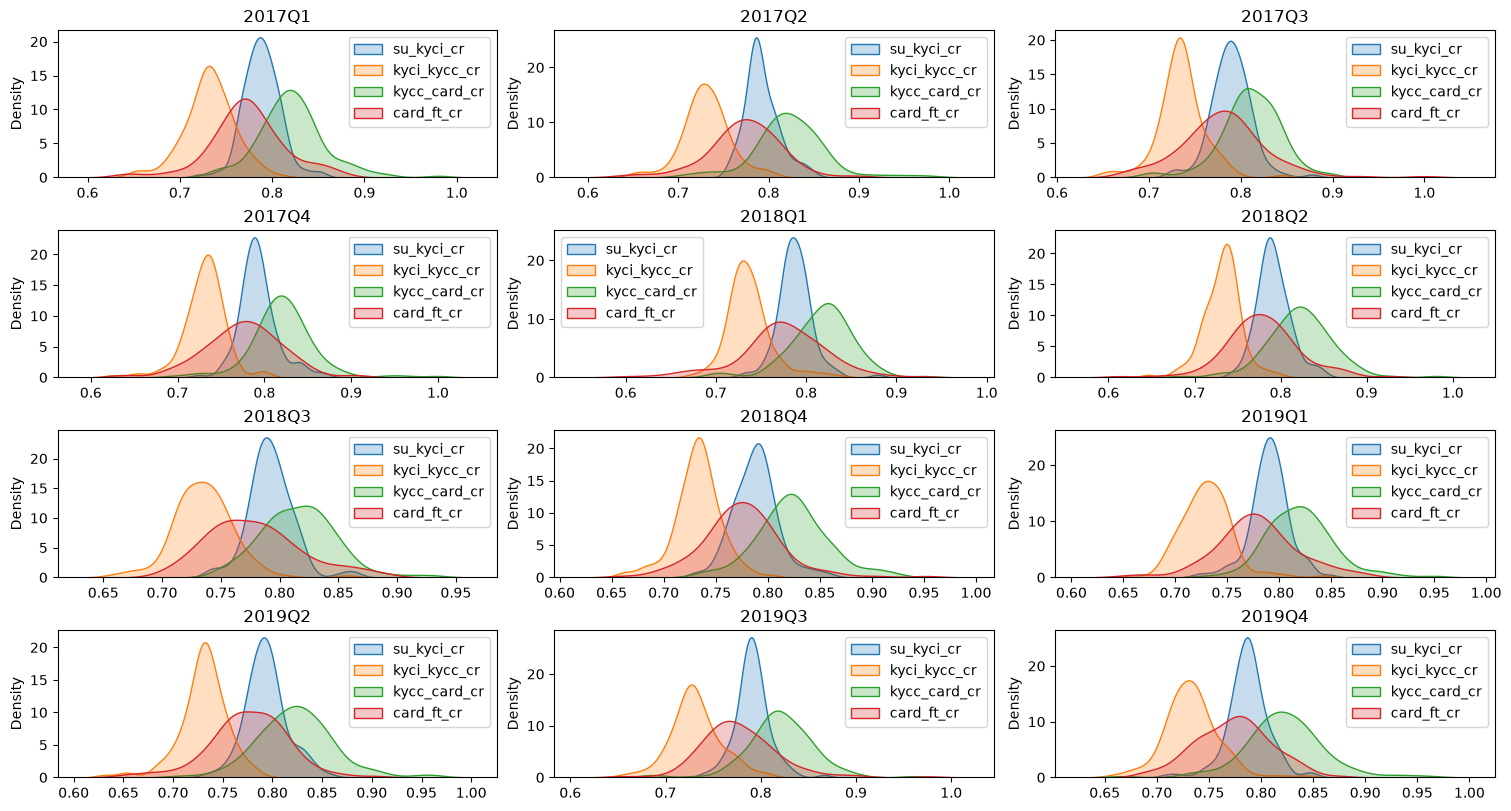

In [9]:
ct_monthly = conversion_table(df, group_by=["month_year", "marketing_channel", "country"])
ct_quarterly = conversion_table(df, group_by=["quarter_year", "marketing_channel", "country"])


plot_kde(ct_quarterly, aggregation_level="quarter_year")

In [24]:
print(f"{round(ct_quarterly["su_ft_cr"].std() * 100, 2)} %")

1.71 %


In [ ]:
m2_summary, m2_outlier = zscore_outlier_scan(df = ct_monthly,
                                           value_cols = ['su_kyci_cr','kyci_kycc_cr', 'kycc_card_cr', 'card_ft_cr', 'su_ft_cr'],
                                           sigma=2)


m2_summary

Rows flagged in >=1 column (|z|>2): 774 / 3835 = % 20.2 
  Flagged rows - median signups: 98
  Clean rows   - median signups: 291


,column,skewness,n_outliers,pct_outliers
0,su_kyci_cr,0.156,243,0.063
1,kyci_kycc_cr,0.134,215,0.056
2,kycc_card_cr,0.239,229,0.060
3,card_ft_cr,0.210,237,0.062
4,su_ft_cr,0.035,222,0.058


In [28]:
m3_summary, m3_outlier = zscore_outlier_scan(df = ct_monthly,
                                           value_cols = ['su_kyci_cr','kyci_kycc_cr', 'kycc_card_cr', 'card_ft_cr', 'su_ft_cr'],
                                           sigma=3)

m3_summary

Rows flagged in >=1 column (|z|>3): 120 / 3835 = % 3.1 
  Flagged rows - median signups: 94
  Clean rows   - median signups: 285


,column,skewness,n_outliers,pct_outliers
0,su_kyci_cr,0.156,31,0.008
1,kyci_kycc_cr,0.134,34,0.009
2,kycc_card_cr,0.239,30,0.008
3,card_ft_cr,0.210,26,0.007
4,su_ft_cr,0.035,10,0.003


**Answer** 

Every cut tells the same story. The weakest step across the whole funnel is KYC init to KYC complete at ~73%, the single biggest leak, and that ordering never changes by channel or country. Across channels, full-funnel conversion runs from 36.4% (brand influencer) to 37.1% (partnership), a spread of 0.71 percentage points, and every individual step sits within roughly one point across all 11 channels.
 
The spread is noise, not signal. The chi-square from the lead already shows no detectable channel effect even at 1.15M signups (chi2 = 9.58, dof = 10, p = 0.478, Cohen's w = 0.003 — negligible on all five funnel steps). Over 36 months the full-funnel rate has a standard deviation of 1.71%, which is a flat line rather than a trend.

The cell-level conversion distribution is symmetric and tight (skew ≈ 0.035 for end-to-end rate): a z-score cut at 3 SD flags 120 rows (3.1%), and loosening to 2 SD flags 774 rows (20.2%) — both groups have a lower median signup count (94 vs 285 at 3 SD; 98 vs 291 at 2 SD), confirming this is small-denominator variance from low-volume cells, not a real performance difference.
 
**The anomaly worth naming is the uniformity itself.** Real channels acquire different cohorts. Paid traffic converts differently from organic, referred users behave differently from display. Identical step conversion across paid, organic, referral, and influencer is not something you see in production, and it is the clearest fingerprint that this data is synthetic.
 
The channels are not even close, but same, and the only real variation left in this data is __volume__.

### Q3: Which channels to recommend for First Transaction

**Plan**

Since step-level conversion is already established as uniform, volume is the only remaining axis to compare across channels. I check the signup distribution to see whether it offers any meaningful differentiation.

I also separate what this dataset can support from what a complete recommendation would actually require. they're different answers.

**Answer**

Conversion is identical across all 11 channels (~36.8% end-to-end), so the only differentiator this dataset offers is signup volume. Every channel or country converts at the same rate, which means more signups directly produces more first transactions. Volume ranges from 24.9k (brand influencer) to 146.5k (other organic), roughly a 6x spread, so scaling the highest-volume channels is the only defensible recommendation with the given dataset.

**That said, volume without cost data doesn't tell us anything in real life**. The highest-volume channel could easily have the worst LTV/CAC. Before taking this to a budget conversation, I'd need spend per channel to calculate CAC, LTV per user to assess return, and upper-funnel metrics like impressions and clicks to understand where marginal investment actually pays off. None of that exists here.

On this dataset: prioritize volume. 
On real data: I wouldn't make a channel investment recommendation without LTV/CAC.

### Q4: Efficiency vs. scale trade-off
 
**Plan** 

The trade-off question is really a plot: full-funnel conversion against signup volume, looking for the channels that lose efficiency as they scale.

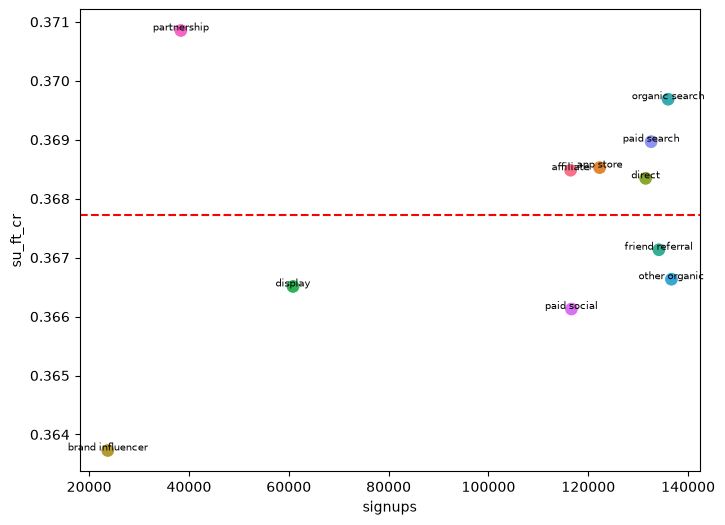

In [30]:
avg_su_ft_cr = mc_cr["su_ft_cr"].mean()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=mc_cr, x="signups", y="su_ft_cr", hue="marketing_channel", s=100, legend=False)
for i in range(len(mc_cr)):
    plt.text(mc_cr["signups"][i], mc_cr["su_ft_cr"][i], mc_cr["marketing_channel"][i], fontsize=7, ha='center')
plt.axhline(avg_su_ft_cr, color="red", linestyle="--", label=f"Avg su_ft_cr: {avg_su_ft_cr:.2f}")
plt.show()

**Answer** 

It does not, and that **absence is the finding**. Normally the high-volume channels convert a little worse, because they reach broader and colder audiences, and that tension is the whole point of the efficiency-versus-scale question. Here the plot is a flat band. The spread between the best and worst channel is (0.007) points, well under one point, with no relationship to volume.
 
On real data this is where it gets interesting. You would plot CAC or LTV/CAC against volume, find the channels that hold efficiency as they scale, and watch for the point where more budget starts dragging conversion down. That curve tells you how far each channel can scale before it stops paying off, and none of its inputs are in this dataset.